# 00 — Analysis of the corpus

French legislatives elections (1981, 1988, 1993)

---

**Author** : Mathéo LEROY — matheo.leroy@ensae.fr  
**Cluster** : Python 3.13.12  

---

## Summary

1. **Overview** & missing values
2. **Length distributions** (by year and by party)
3. **Global vocabulary** (top words, n-grams)
4. **Comparative lexical density**
5. **Wordclouds** by year (temporal perspective)
6. **TF-IDF** — most distinctive terms by year
7. **Metadata** — gender, age, profession, mandates, geography, ticket parity
8. **Stopwords**

---

# 1. Imports et configuration

---

In [105]:
%pip install numpy pandas matplotlib seaborn scikit-learn fastparquet nltk wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [106]:
import sys
import os
from pathlib import Path

os.chdir("../")
path_to_add = "/Users/matheoleroy/Desktop/nlp/"
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

print("Python executable:", sys.executable)
print("Python path:", sys.path)

Python executable: /Users/matheoleroy/Desktop/nlp/.venv/bin/python
Python path: ['/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/matheoleroy/Desktop/nlp/.venv/lib/python3.13/site-packages', '/Users/matheoleroy/Desktop/nlp/']


In [107]:
# ---------------------------------------------------------------
# Importing modules for data anylsis and visualization
# ---------------------------------------------------------------
%load_ext autoreload
%autoreload 2

import analysis_dataset as eda

# Graphics configuration
eda.setup_matplotlib()

# Natural language processing configuration
eda.setup_nltk()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Matplotlib configured with custom style and palettes.


In [108]:
# ---------------------------------------------------------------
# Loading data and preprocessing
# ---------------------------------------------------------------
# `load_dataset` read the parquet file, normalizes the `date` column and automatically constructs
# the `party` column from `titulaire-soutien` by applying the normalization rules defined in the module.

PARQUET_PATH = "/Users/matheoleroy/Downloads/data_nlp/legislatives_metadata.parquet"

df = eda.load_dataset(PARQUET_PATH)
df.head()


Dataset loaded : 12746 documents, 46 columns.

Party distribution (after normalization) :
party
UNKNOWN             3297
DROITE              2238
COMMUNISTE          1563
SOCIALISTE          1561
EXTREME_DROITE      1373
ECOLOGISTE          1243
EXTREME_GAUCHE       637
CENTRE_DROIT         370
COALITION_GAUCHE     227
DIVERS               195
CENTRE                42
Name: count, dtype: int64


,id,text,source,date,date_meta,subject,title,contexte-election,contexte-tour,cote,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,party
0,EL135_L_1981_06_062_11_1_PF_02,Sciences Po / fonds CEVIPOF\nCANDIDAT SUPPLEAN...,/home/onyxia/work/NLP_mini_project/text_files/...,1981,1981-06-14,Ve République;France;Assemblée Nationale;Élect...,"Élections législatives de 1981, Pas-de-Calais ...",législatives,1.0,EL135,...,non mentionné,non mentionné,maire-adjoint,non mentionné,école,non mentionné,Parti socialiste,non mentionné,non,SOCIALISTE
1,EL136_L_1981_06_067_05_1_PF_05,Sciences Po / fonds CEVIPOF\nElections Législa...,/home/onyxia/work/NLP_mini_project/text_files/...,1981,1981-06-14,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1981, Bas-Rhin - 67,...",législatives,1.0,EL136,...,non mentionné,conseiller entreprise,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,Union pour une nouvelle majorité,non,DROITE
2,EL134_L_1981_06_035_01_1_PF_01,Sciences Po / fonds CEVIPOF\nElections législa...,/home/onyxia/work/NLP_mini_project/text_files/...,1981,1981-06-14,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1981, Ille-et-Vilain...",législatives,1.0,EL134,...,entre 20 et 29 ans,institutrice,non mentionné,non mentionné,non mentionné,non mentionné,Lutte ouvrière,non mentionné,non,EXTREME_GAUCHE
3,EL135_L_1981_06_062_11_1_PF_01,ÉLECTIONS LÉGISLATIVES DU 14 JUIN 1981 - 11e C...,/home/onyxia/work/NLP_mini_project/text_files/...,1981,1981-06-14,France;Ve République;Assemblée Nationale;Élect...,"Élections législatives de 1981, Pas-de-Calais ...",législatives,1.0,EL135,...,non mentionné,non mentionné,conseiller général;maire,non mentionné,non mentionné,non mentionné,Parti communiste français,Union de la gauche,non,COMMUNISTE
4,EL134_L_1981_06_021_04_1_PF_02,République Française\nELECTIONS LEGISLATIVES D...,/home/onyxia/work/NLP_mini_project/text_files/...,1981,1981-06-14,France;Élections législatives;Ve République;As...,"Élections législatives de 1981, Côte-d'Or - 21...",législatives,1.0,EL134,...,non mentionné,non mentionné,conseiller général;maire,député,non mentionné,non mentionné,Mouvement des radicaux de gauche,non mentionné,non,SOCIALISTE


In [109]:
# ---------------------------------------------------------------------------
# Language detection and flagging german documents
# ---------------------------------------------------------------------------

df_flag_german = eda.flag_german_documents(df, text_col="text", stopword_threshold=0.05)

# Summary statistics
print("\n=== Detected Languages ===")
print(df_flag_german["lang"].value_counts())

print(f"\n=== Documents flagged as German : {df_flag_german['is_german'].sum()} ===")

suspects = df_flag_german[df_flag_german["is_german"]].sort_values("german_score", ascending=False)
cols_preview = ["id", "lang", "german_score", "party", "date"]
cols_preview = [c for c in cols_preview if c in df_flag_german.columns]
print("\nTop 20 documents flagged as German :")
print(suspects[cols_preview].head(20).to_string())


Number of documents: 12746

=== Detected Languages ===
lang
fr    12705
de       19
en       12
ca        5
it        3
sw        1
et        1
Name: count, dtype: int64

=== Documents flagged as German : 1761 ===

Top 20 documents flagged as German :
                                   id lang  german_score           party  date
5935   EL176_L_1988_06_067_06_1_PF_02   de      0.419552    CENTRE_DROIT  1988
9421   EL194_L_1993_03_067_09_2_PF_01   fr      0.253772    CENTRE_DROIT  1993
7788   EL192_L_1993_03_057_06_1_PF_07   fr      0.239814  EXTREME_GAUCHE  1993
949    EL136_L_1981_06_067_03_1_PF_04   fr      0.238770         UNKNOWN  1981
6670   EL176_L_1988_06_068_06_2_PF_02   fr      0.238095         UNKNOWN  1988
2235   EL136_L_1981_06_067_05_1_PF_03   fr      0.234608      ECOLOGISTE  1981
2374   EL136_L_1981_06_068_01_1_PF_03   fr      0.234304      ECOLOGISTE  1981
543    EL136_L_1981_06_068_02_1_PF_03   fr      0.234153      ECOLOGISTE  1981
894    EL136_L_1981_06_068_04_1_PF_05

This example shows some document based on Alsace , translates their speech into german. We need to filter those german texts.

In [110]:
df[df["id"]=="EL194_L_1993_03_067_09_2_PF_01"]["text"].values[0]

"8e CIRCONSCRIPTION - ELECTIONS LÉGISLATIVES DES 21 ET 28 MARS 1993 Lauterbourg - Niederbronn - Seltz - Soultz-sous-Forêts - Wissembourg - Wærth\nMes chers concitoyens,\nT out d'abord, merci à toutes celles et à tous ceux qui, dimanche dernier m'ont accordé d'emblée leur confiance.\nVous avez clairement affirmé votre volonté de changement et de renouveau et refusé de vous faire imposer le candidat de l'appareil R.P.R., qui, pourtant à priori favori, ne totalise à peine plus d'un tiers des voix. Même dans sa propre ville il n'a pas obtenu la majorité des suffrages. Ne vous laissez pas abuser par les soutiens de circonstance !\nL'espoir est né le 21 Mars. Ensemble, dimanche, quelque soit votre choix du 1er tour, vous devez faire triompher cet espoir.\nCe choix est aujourd'hui simple : il faut voter pour l'homme qui saura incarner nos aspirations au changement et saura dignement vous représenter.\nJe suis cet homme du renouveau qui à l'Assemblée Nationale représentera aussi bien les trava

In [111]:
df_flag_german_with_french = eda.add_french_only_column(df_flag_german, text_col="text", only_flagged=True)

print(df_flag_german_with_french.loc[df_flag_german_with_french["is_german"], ["id", "removed_ratio"]]
        .sort_values("removed_ratio", ascending=False).head(20))

print(df_flag_german_with_french.loc[df_flag_german_with_french["is_german"], ["id", "removed_ratio"]]
        .sort_values("removed_ratio", ascending=True).head(20))

i = df_flag_german_with_french[df_flag_german_with_french["is_german"]].index[0]
print("=== BEFORE ===\n", df_flag_german_with_french.loc[i, "text"][:500])
print("\n=== AFTER ===\n", df_flag_german_with_french.loc[i, "text_fr"][:500])

Filtrage de l'allemand sur 1761 documents marqués...
                                             id  removed_ratio
6806   EL174_L_1988_06_006_01_1_BV_pdfmasterocr            1.0
807    EL134_L_1981_06_014_01_2_BV_pdfmasterocr            1.0
2165             EL134_L_1981_06_025_01_1_PF_09            1.0
2157   EL137_L_1981_06_095_05_2_BV_pdfmasterocr            1.0
10623  EL189_L_1993_03_013_06_1_BV_pdfmasterocr            1.0
7414   EL189_L_1993_03_003_01_1_BV_pdfmasterocr            1.0
7483   EL190_L_1993_03_025_03_1_BV_pdfmasterocr            1.0
8510   EL192_L_1993_03_044_05_1_BV_pdfmasterocr            1.0
10674  EL189_L_1993_03_013_15_1_BV_pdfmasterocr            1.0
5865   EL174_L_1988_06_004_02_2_BV_pdfmasterocr            1.0
10743  EL198_L_1993_03_093_11_1_BV_pdfmasterocr            1.0
4708   EL174_L_1988_06_006_05_1_BV_pdfmasterocr            1.0
7526   EL191_L_1993_03_042_05_1_BV_pdfmasterocr            1.0
11700  EL190_L_1993_03_025_02_1_BV_pdfmasterocr            1.0
84

In [112]:
#df_flag_german_with_french.to_parquet("/Users/matheoleroy/Downloads/data_nlp/legislatives_metadata_flagged.parquet", index=False)

# 2. Analysis 

---

## 2.0 Party Distribution

/Users/matheoleroy/Desktop/nlp/analysis_dataset.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  MAPPING_FILE_PATH = "/Users/matheoleroy/Downloads/data_nlp/mapping_partis_familles_1.txt"


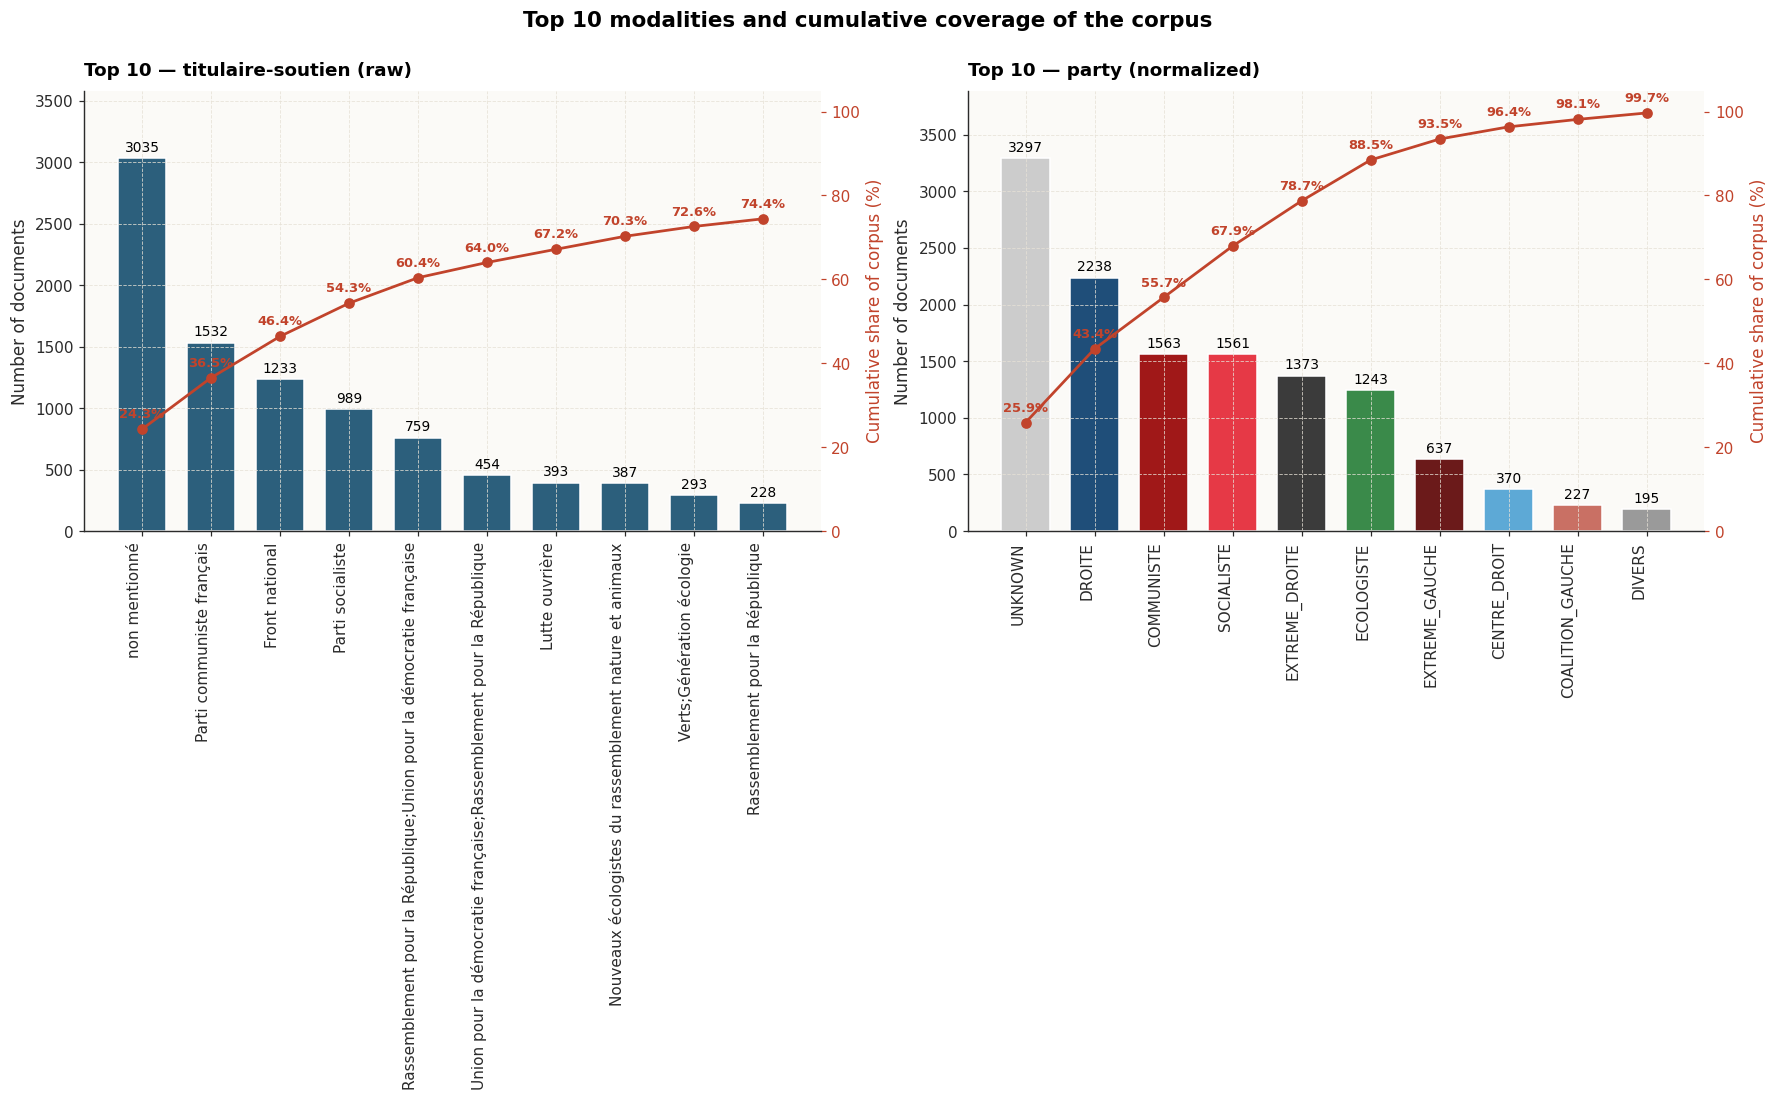

In [113]:
eda.plot_top_titulaire_party_pareto(df, top_n=10)

## 2.1 Overview

In [114]:
# Synthesis of the corpus:  ,
eda.overview(df, n_top_parties=12)


  Documents      :  12746
  Columns       : ['id', 'text', 'source', 'date', 'date_meta', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'party']

Missing values :


,id,text,source,date,date_meta,subject,title,contexte-election,contexte-tour,cote,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,party
n_missing,0,0,0,0,249,249,249,249,249,249,...,249,249,249,249,250,249,249,249,249,0



Documents per year :
  1981 :  3182  █████████████████████
  1988 :  3628  ████████████████████████
  1993 :  5936  ████████████████████████████████████████


## 2.2 Length Distributions 

In [115]:
eda.compute_text_lengths(df)


       text_length  word_count
count      12746.0     12746.0
mean        3929.2       625.8
std         2058.6       331.3
min           63.0         9.0
25%         2464.0       391.0
50%         3504.5       557.0
75%         5212.8       830.0
max        50611.0      8255.0


,text_length,word_count
count,12746.0,12746.0
mean,3929.2,625.8
std,2058.6,331.3
min,63.0,9.0
25%,2464.0,391.0
50%,3504.5,557.0
75%,5212.8,830.0
max,50611.0,8255.0


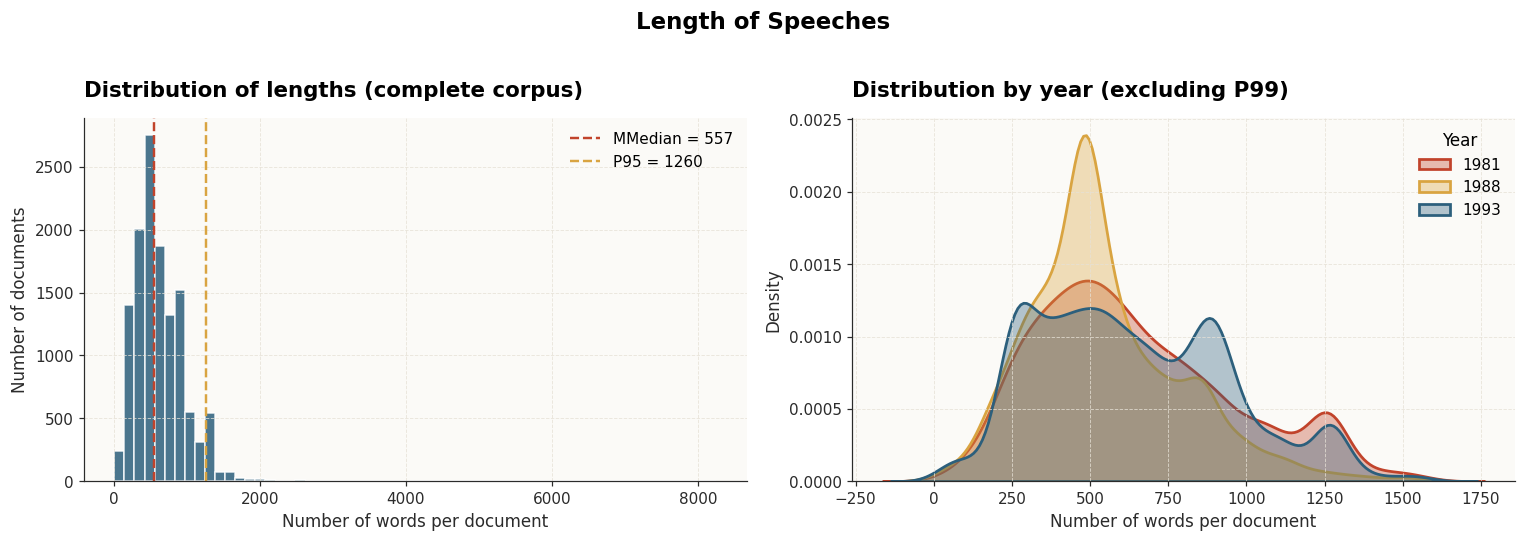

In [116]:
# Figure 1 : distribution of text lengths (characters and words)
eda.plot_length_distribution(df)


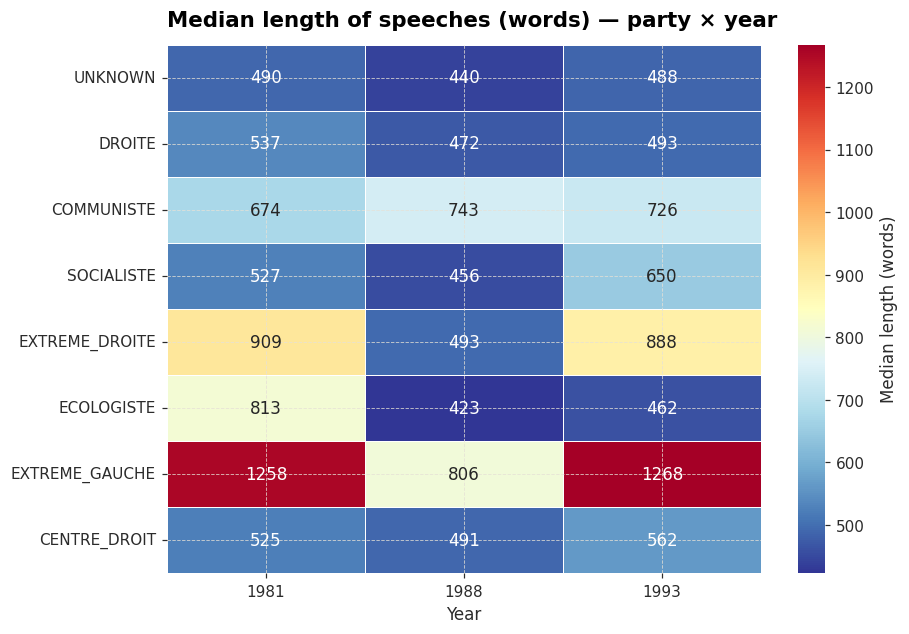

In [117]:
# Figure 2 : median length by party × year (heatmap)
eda.plot_length_by_party_year(df, top_n_parties=8)


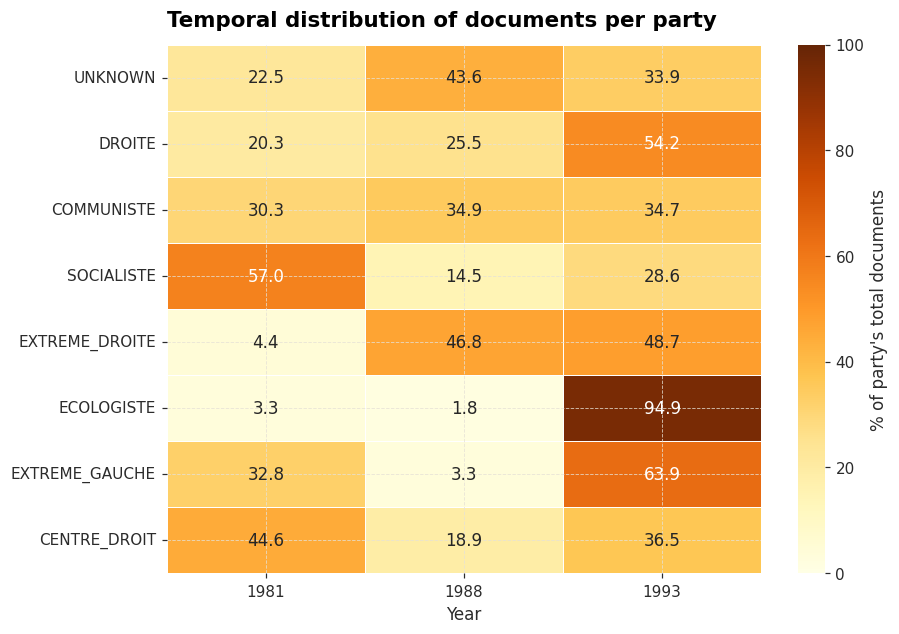


Raw document counts (party × year):
date            1981  1988  1993
party                           
UNKNOWN          741  1438  1118
DROITE           455   570  1213
COMMUNISTE       474   546   543
SOCIALISTE       889   226   446
EXTREME_DROITE    61   643   669
ECOLOGISTE        41    22  1180
EXTREME_GAUCHE   209    21   407
CENTRE_DROIT     165    70   135


In [133]:
eda.plot_doc_share_by_party_year(df, top_n_parties=8)

## 2.3 Global Vocabulary

In [120]:
# quick Tokenisation NLTK  → add the `tokens` column to the DataFrame.
# for les wordclouds et le TF-IDF distinctif).
word_freq, fr_stopwords = eda.quick_tokenize_corpus(df)


Tokenisation NLTK : 19.9s
Global vocabulary : 88,619 unique words | 3,907,022 tokens.


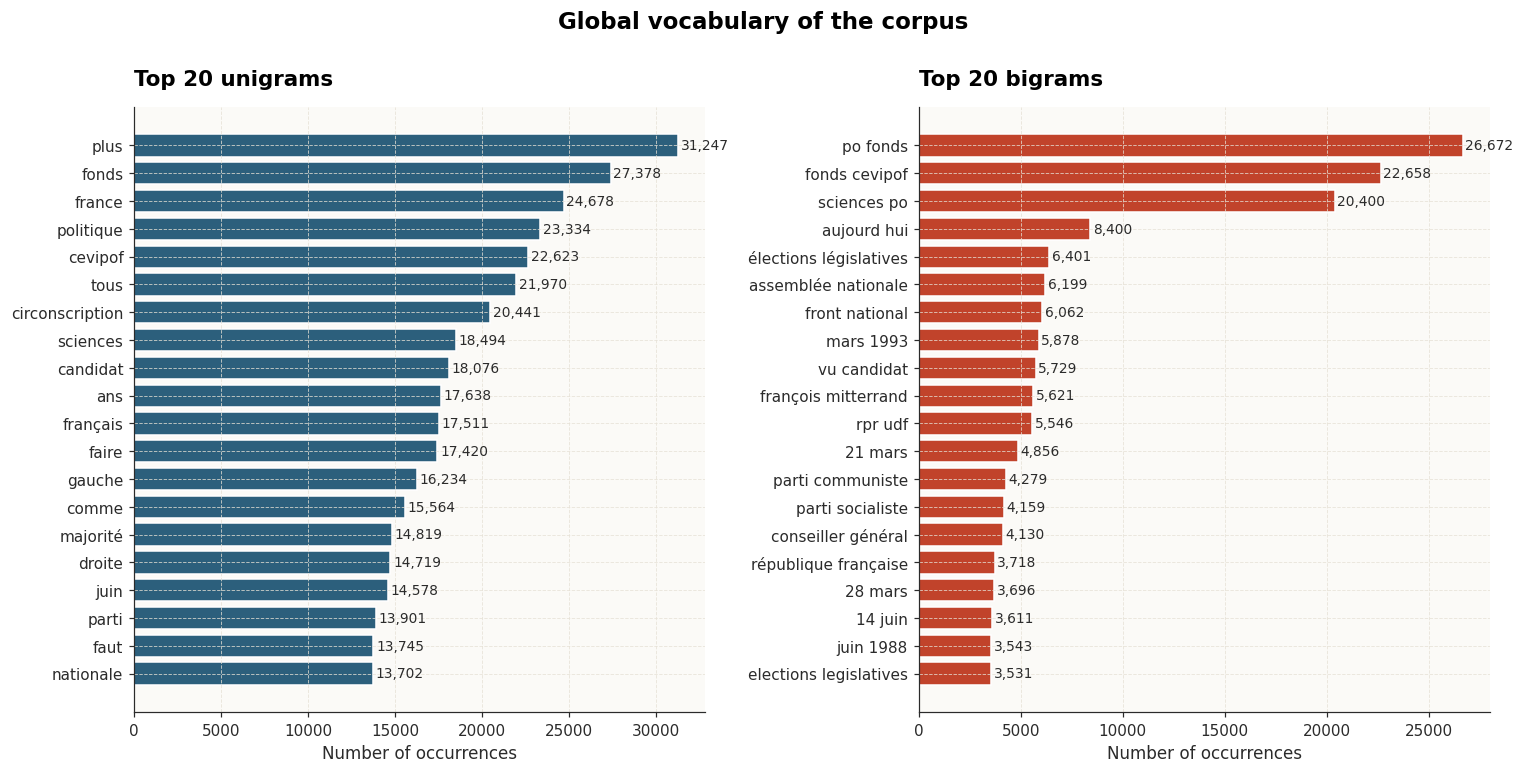

In [121]:
# Figure 3 : top 20 unigrams + top 20 bigrams
eda.plot_top_words_and_bigrams(df, word_freq, fr_stopwords, n=20)


## 2.4 Densité lexicale par année et par parti

In [122]:
# Densité lexicale = vocabulaire unique / nombre total de mots
# Plus elle est élevée, plus le texte évite les répétitions.
eda.compute_lexical_density(df)


count    12746.000
mean         0.380
std          0.044
min          0.136
25%          0.354
50%          0.377
75%          0.404
max          0.789
Name: lexical_density, dtype: float64


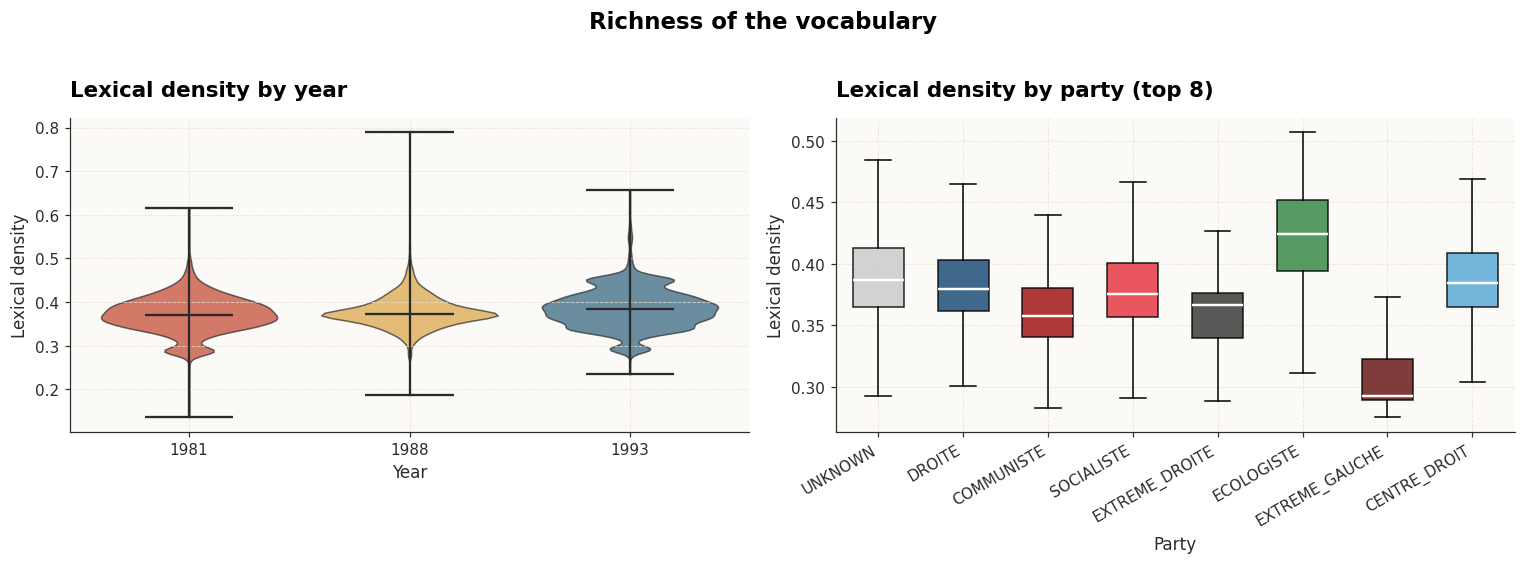

In [123]:
# Figure 4 : violons par année + boxplots par parti
eda.plot_lexical_density(df, top_n_parties=8)


## 2.5 Wordclouds — évolution temporelle

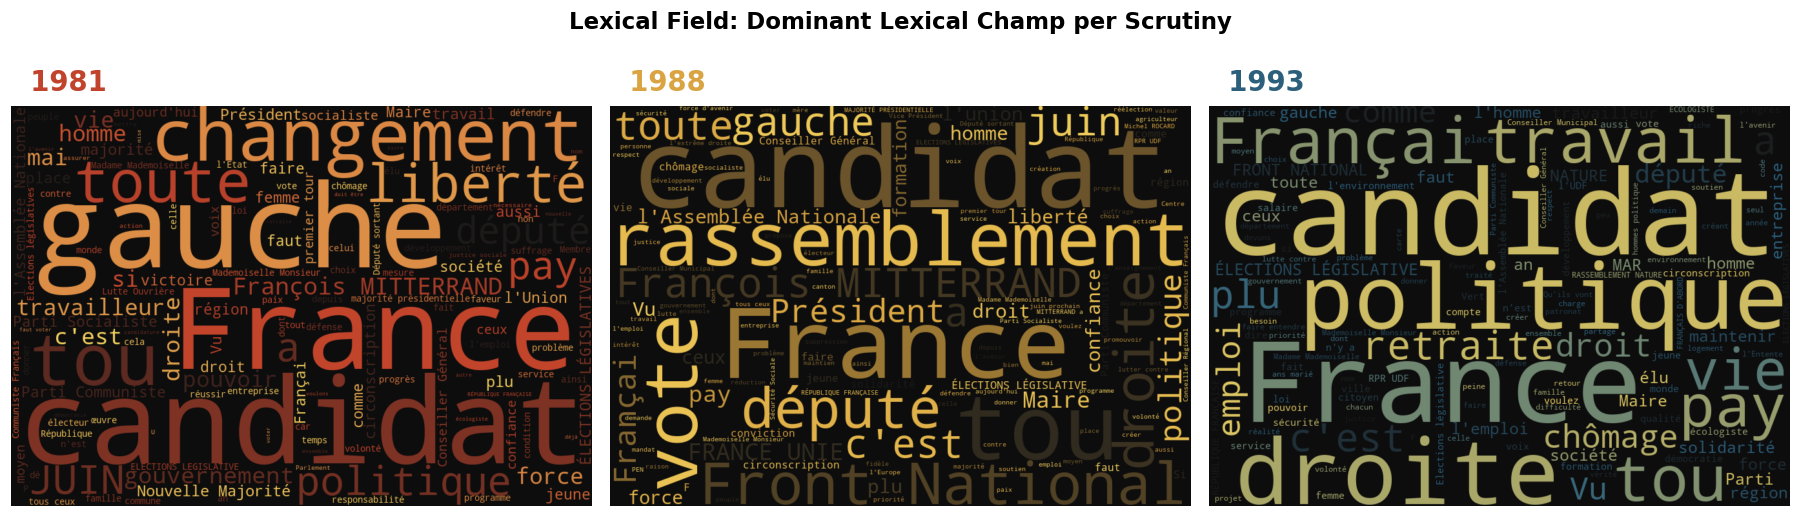

In [124]:
# Figure 5 : a wordcloud per year (3 plots)
eda.plot_wordclouds_by_year(df, fr_stopwords, max_words=140, extra_stopwords={"sciences", "po", "sciencespo", "fonds", "fond", "cevipof"})


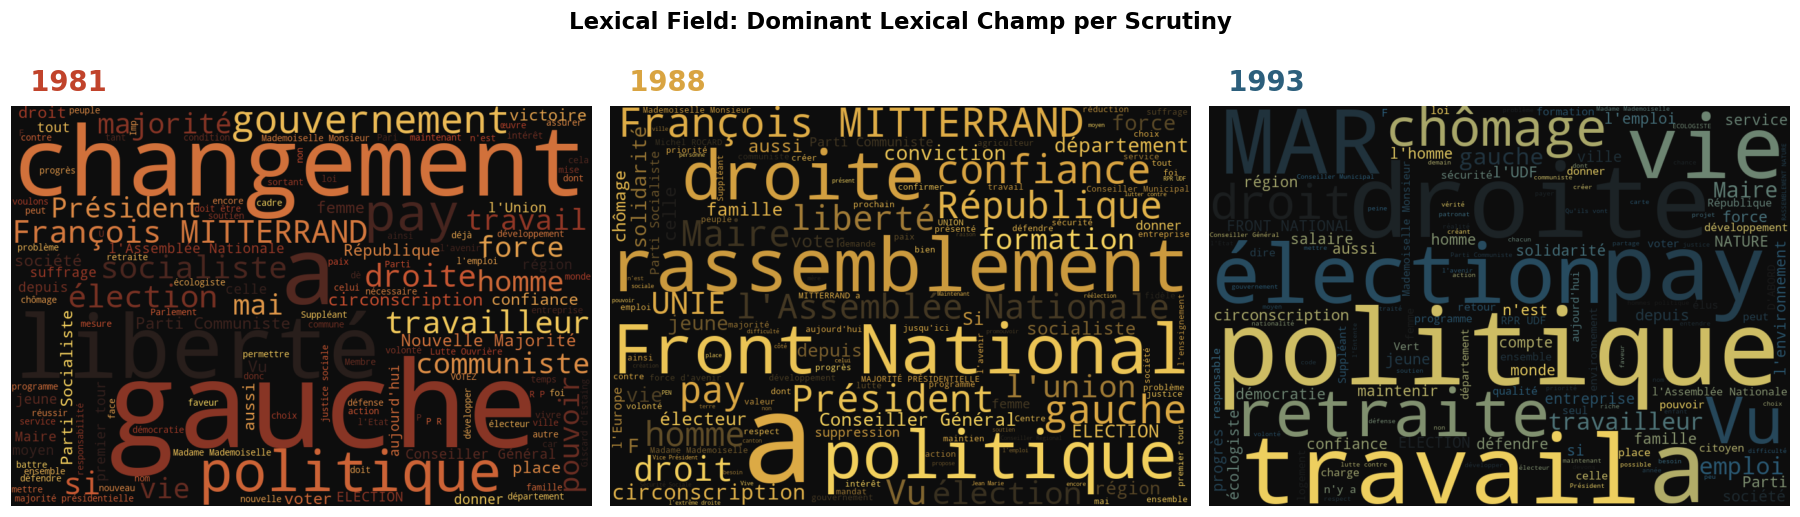

In [125]:
eda.plot_wordclouds_by_year(df, fr_stopwords, max_words=140, extra_stopwords={"sciences", "toutes", "ceux", "po", "tous", "sciencespo", "fonds", "fond", "cevipof", "france", "française", "français", "francais", "francaises", "françaises", "francaises", "candidats", "candidat", "candidatures", "candidature", "comme", "juin", "c'est", "ce", "cette", "ces", "il", "elle", "ils", "elles", "on", "nous", "vous", "leur", "leurs", "élu", "vote", "plu", "tou", "toute", "voix", "plus", "LEGISLATIVE", "législative", "législatives", "legislative", "legislatives", "an", "ans", "voulez", "faire", "fait", "faire", "faites", "faites", "voulez", "vouloir", "voulez-vous", "voulez vous", "faut", "circonscriptions", "circo", "circonscriptions", "circos", "circo", "circonscriptions", "circos", "député", "députés", "deputé", "deputés"})


## 2.6 TF-IDF — termes les plus distinctifs

Contrairement aux comptages bruts, le TF-IDF met en avant les mots
**caractéristiques** d'un document ou d'un sous-corpus. Ici on cherche les
termes les plus distinctifs **par année**, ce qui constitue un premier indice
de l'évolution thématique.

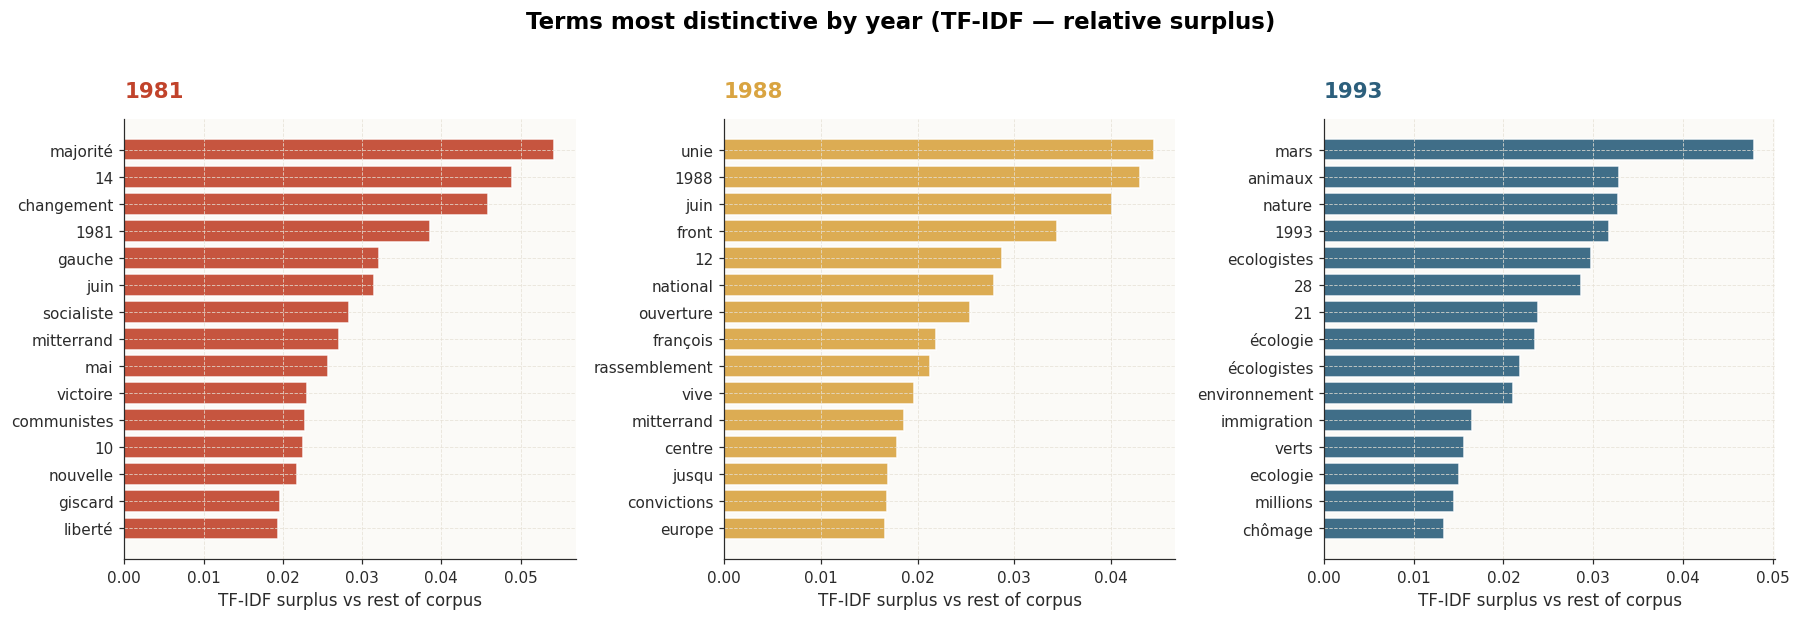

In [126]:
# Figure 6 : top 15 termes distinctifs par année (surplus de TF-IDF)
extra_stop = {"sciences", "toutes", "ceux", "po", "tous", "sciencespo", "fonds", "fond", "cevipof", "france", "française", "français", "francais", "francaises", "françaises", "14", "1981", "mai", "10", "nouvelle", "juin", "1988", "12", "jusqu", "mars", "1993", "28", "21",}
eda.plot_tfidf_distinctive_words(df, fr_stopwords, n=15, max_features=3000)


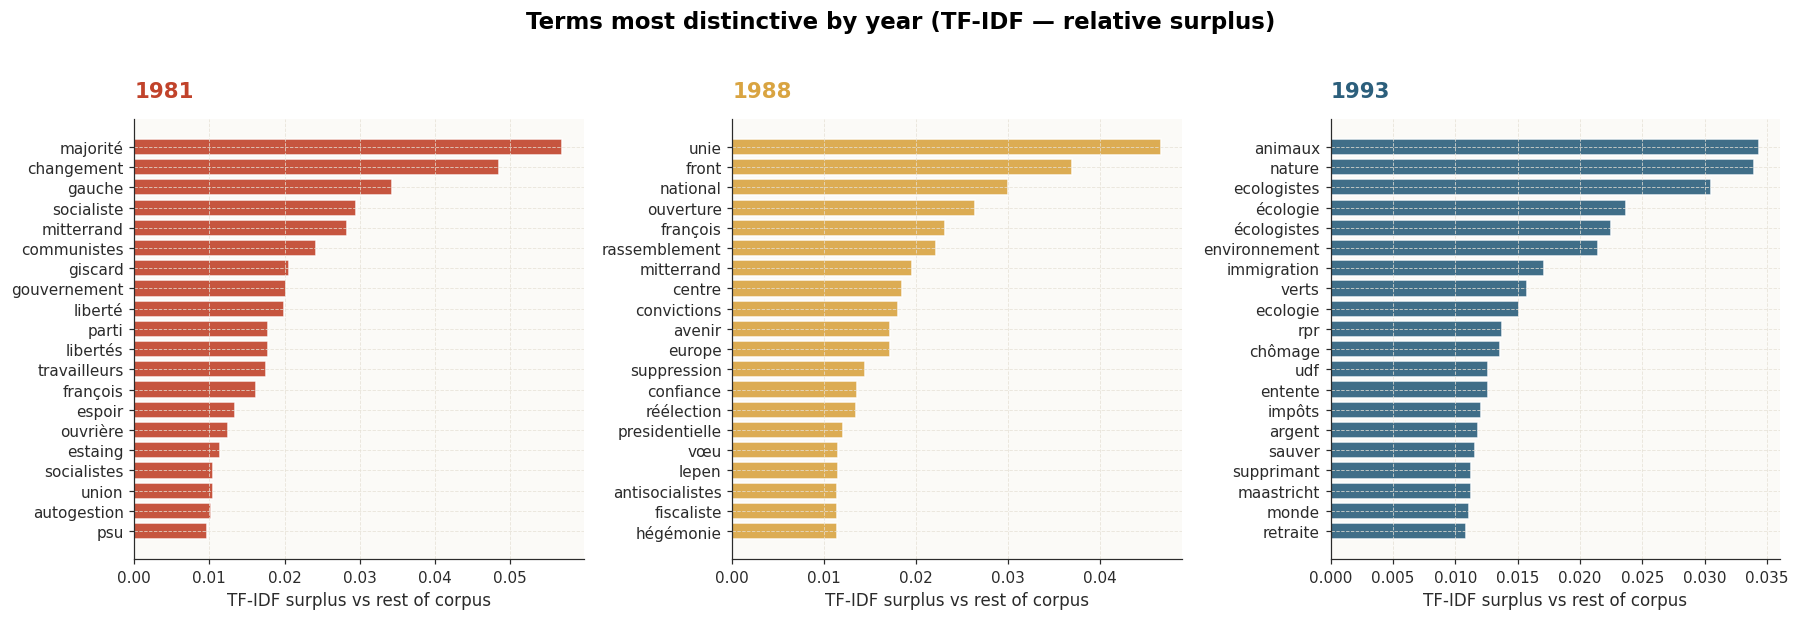

In [127]:
extra_stop = {"sciences", "toutes", "ceux", "po", "tous", "sciencespo", "présidentielles", "absents", "conseiller","place", "voeu", "président", "ministres", "présidentielle", "michel", "carte", "nationale", "maire", "électeurs", "députés", "élection", "24", "vive", "tour", "pouvoir", "mesures", "quotas", "rocard", "activités", "victoire", "défaite", "ici", "réussir", "millions", "1978", "faites", "nouveaux", "communiste", "fonds", "vote", "code", "existence", "faut", "présidentielle", "fond", "cevipof", "france", "française", "français", "francais", "francaises", "françaises", "14", "1981", "mai", "10", "nouvelle", "juin", "1988", "12", "jusqu", "mars", "1993", "28", "21",}
eda.plot_tfidf_distinctive_words(df, fr_stopwords | extra_stop, n=20, max_features=3000)


## 2.7 Analyses descriptives sur les métadonnées

Avant d'attaquer le topic modeling, on profite des **métadonnées riches**
(profil sociodémographique des candidats, mandats détenus, géographie,
présence du suppléant) pour dresser un portrait du corpus. Ces analyses
éclairent ensuite l'interprétation des thèmes : un parti dont les candidats
sont majoritairement des élus locaux ne mobilise pas le même vocabulaire
qu'un parti porté par des outsiders.

Les colonnes utilisées ici sont préfixées `titulaire-` (candidat) et
`suppleant-` (suppléant).

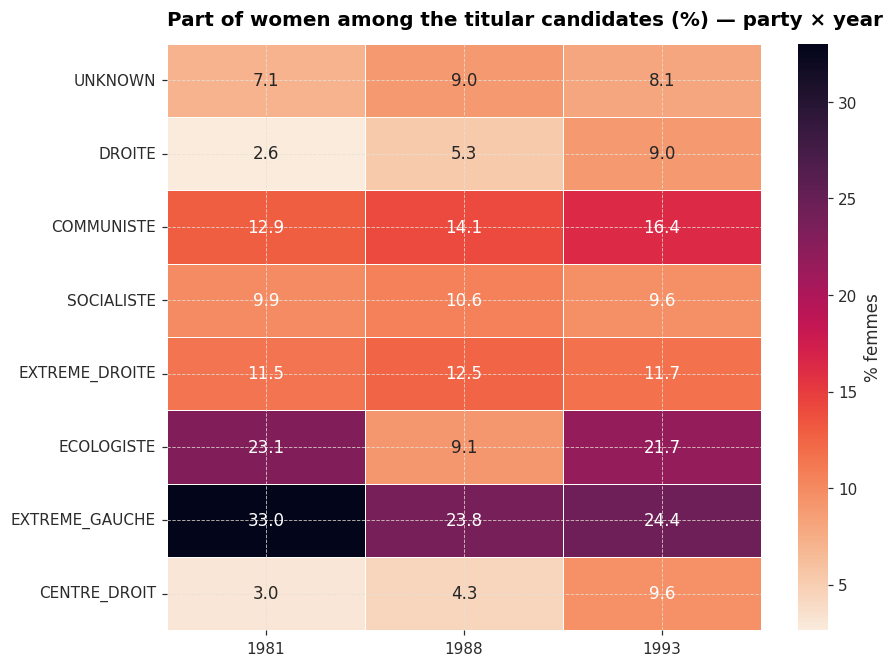


Global part of women among the titular candidates (%) :
date
1981    10.1
1988     9.9
1993    12.6


In [128]:
# Figure 5a — Part des femmes parmi les candidats titulaires
#              (heatmap parti × année)
eda.plot_women_share_by_party_year(df, top_n_parties=8)


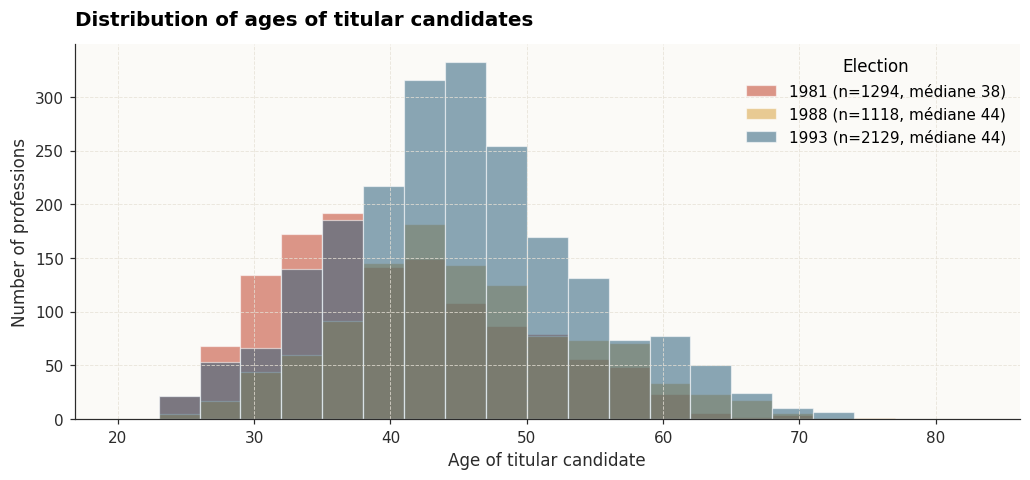

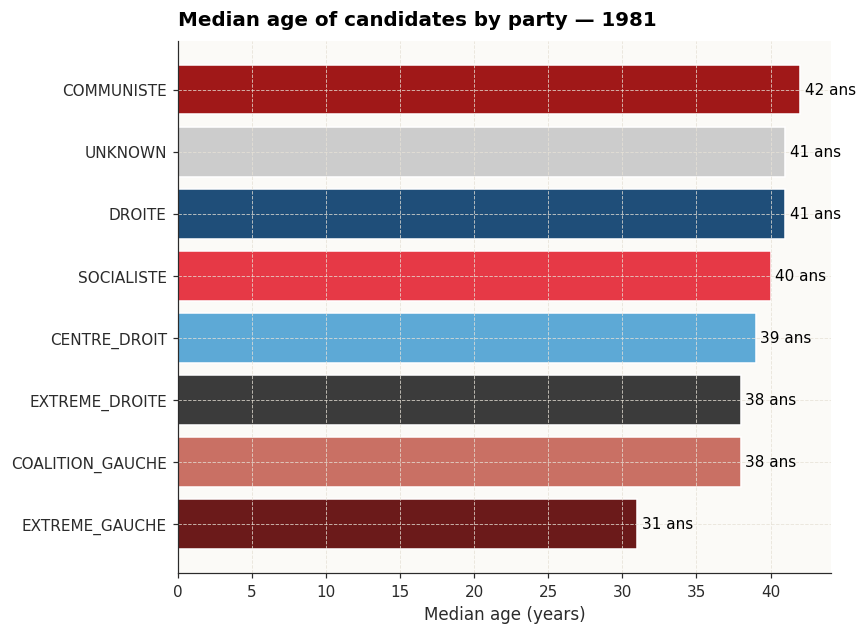

In [129]:
# Figure 5b — Distribution des âges par année + âge médian par parti
#              sur l'année cible (1981 par défaut)
eda.plot_age_distribution(df, year_focus="1981", top_n_parties=8)


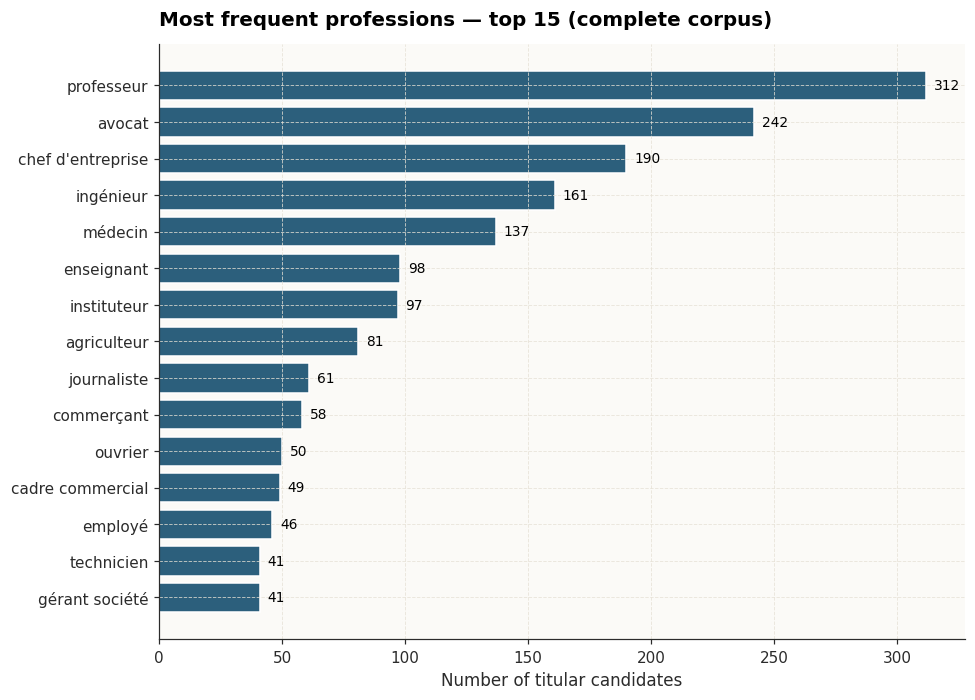

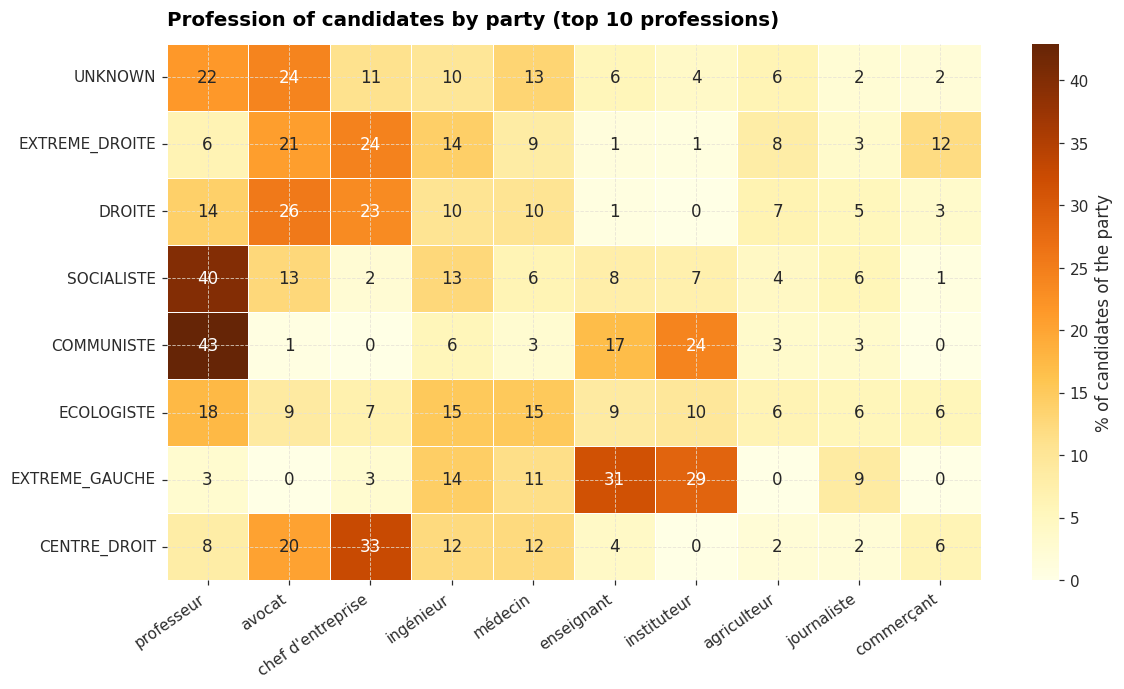

In [130]:
# Figure 5c — Professions des candidats : top global + heatmap
#              parti × profession
eda.plot_top_professions(df, top_n_global=15, top_n_parties=8, top_n_prof=10)


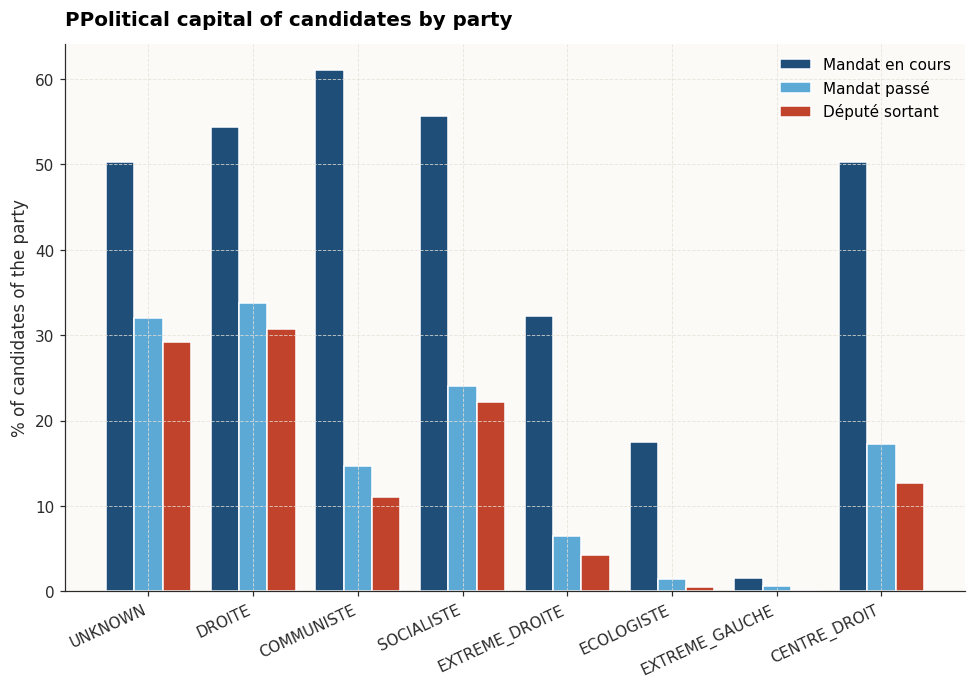


Détail (in %) :
                Mandat en cours  Mandat passé  Député sortant
party                                                        
UNKNOWN                    50.3          32.0            29.2
DROITE                     54.4          33.8            30.7
COMMUNISTE                 61.1          14.7            11.1
SOCIALISTE                 55.7          24.1            22.2
EXTREME_DROITE             32.3           6.5             4.2
ECOLOGISTE                 17.5           1.4             0.5
EXTREME_GAUCHE              1.6           0.6             0.0
CENTRE_DROIT               50.3          17.3            12.7


In [131]:
# Figure 5d — Capital politique : part des candidats avec un mandat
#              (en cours / passé / sortant) par parti
eda.plot_political_capital(df, top_n_parties=8)


The corpus covers 106 distinct departments.


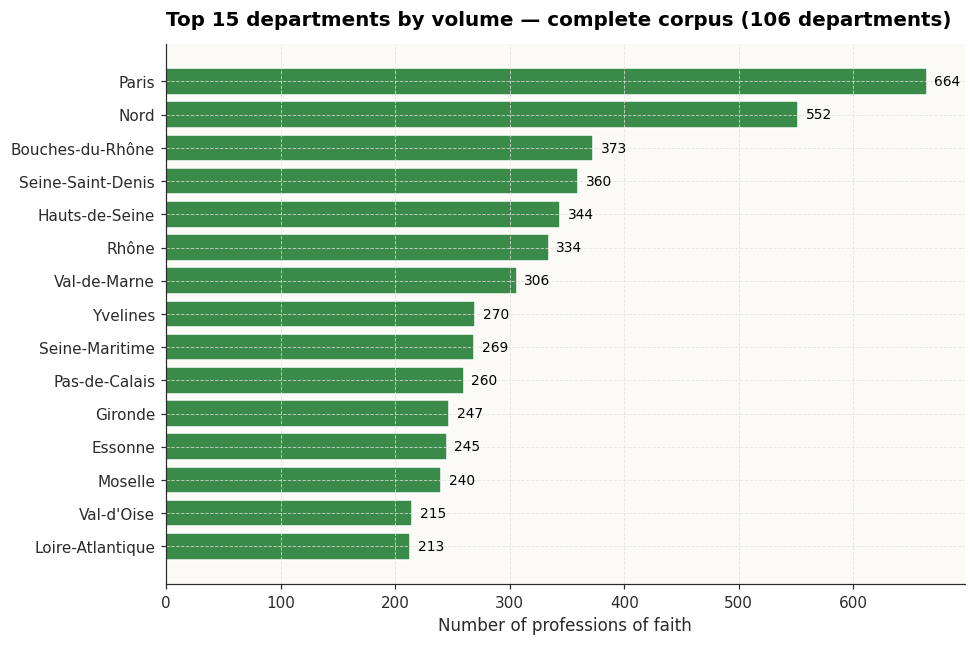

In [132]:
# Figure 5e — Couverture géographique du corpus (top 15 départements)
eda.plot_geographic_coverage(df, top_n_dept=15)


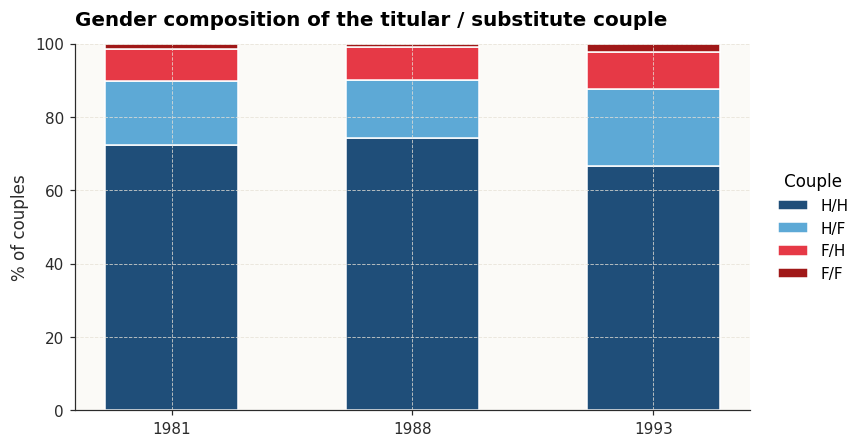


Repartition (%) of couples per election :
binome   H/H   H/F   F/H  F/F
date                         
1981    72.4  17.4   8.7  1.5
1988    74.4  15.8   8.8  1.0
1993    66.6  21.0  10.1  2.3


In [ ]:
# Figure 5f — Composition genrée du binôme titulaire / suppléant
#              (H/H, H/F, F/H, F/F) par année
eda.plot_ticket_gender_composition(df)


## 2.8. Detect extra stopwords related to politics and the subject studied here

Before modeling topic, we are looking for words that appear for each party, these are job-related political words, that does not convey 
any thematic information. Conversely, discriminant words between partys are useful and should be kept.

On use two scores which are complementary on the column `tokens` (already cleaned without stopwords NLTK) :

- **CV inter-partis** = std / mean of relative frequencies per party. low CV + high frequencies ⇒ transversal word ⇒ stopword.
- **normalized entropy** on the party distribution. close to 1 ⇒ uniformed repartition  ⇒ stopword.

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd

# we exclude UNKNOWN for the inter-party calculation, as it's a noisy default label for missing data.
df_disc = df[df["party"] != "UNKNOWN"].copy()
parties_arr = df_disc["party"].values
tokens_lists = df_disc["tokens"].tolist()  

# Pre-calculation : a Counter per party + total tokens per party (1 pass)
counters_par_parti = {}
totaux_par_parti = {}
for parti in set(parties_arr):
    mask = parties_arr == parti
    sub_tokens = [t for t, m in zip(tokens_lists, mask) if m]
    flat = [w for doc in sub_tokens for w in doc]
    counters_par_parti[parti] = Counter(flat)
    totaux_par_parti[parti] = len(flat)

partis_list = list(counters_par_parti.keys())
print(f"Partis pris en compte : {partis_list}")
print(f"Tokens totaux par parti : "
      f"{ {p: totaux_par_parti[p] for p in partis_list} }")


def scores_mot(word):
    """Return (CV, entropie_normalisée, freq_globale, freqs_relatives_par_parti)
    pour un mot donné, sur la base des Counters pré-calculés."""
    freqs = {
        p: counters_par_parti[p].get(word, 0) / max(totaux_par_parti[p], 1)
        for p in partis_list
    }
    vals = np.array(list(freqs.values()))
    cv = vals.std() / (vals.mean() + 1e-12)

    # normalized entropy on the distribution (parts per party, sum=1)
    s = vals.sum()
    if s == 0:
        ent_norm = 0.0
    else:
        p = vals / s
        p = p[p > 0]
        ent = -(p * np.log(p)).sum()
        ent_norm = ent / np.log(len(partis_list))  # ∈ [0, 1]

    freq_globale = sum(counters_par_parti[p].get(word, 0) for p in partis_list) / \
                   sum(totaux_par_parti[p] for p in partis_list)
    return cv, ent_norm, freq_globale, freqs


# Test rapide sur les mots fournis (sanity check)
print("\n--- Reference ---")
print(f"{'word':15s}  {'CV':>6s}  {'entropie':>8s}  {'freq‰':>6s}")
for w in ["gouvernement", "majorité", "français", "président",
          "politique", "liste", "tour", "mandat", "député"]:
    cv, ent, fg, _ = scores_mot(w)
    print(f"{w:15s}  {cv:6.2f}  {ent:8.3f}  {fg*1000:6.2f}")

Partis pris en compte : ['EXTREME_GAUCHE', 'SOCIALISTE', 'DROITE', 'COALITION_GAUCHE', 'CENTRE', 'COMMUNISTE', 'EXTREME_DROITE', 'DIVERS', 'ECOLOGISTE', 'CENTRE_DROIT']
Tokens totaux par parti : {'EXTREME_GAUCHE': 344994, 'SOCIALISTE': 452389, 'DROITE': 617460, 'COALITION_GAUCHE': 78383, 'CENTRE': 12670, 'COMMUNISTE': 562642, 'EXTREME_DROITE': 485418, 'DIVERS': 58442, 'ECOLOGISTE': 333453, 'CENTRE_DROIT': 106588}

--- Reference ---
word                 CV  entropie   freq‰
gouvernement       0.67     0.901    2.04
majorité           0.51     0.935    3.64
français           1.04     0.822    4.93
président          0.67     0.890    1.84
politique          0.33     0.974    6.27
liste              1.11     0.801    0.30
tour               0.54     0.930    1.91
mandat             0.57     0.945    0.47
député             0.48     0.942    2.79


In [ ]:
STOPWORDS_PATH = "/Users/matheoleroy/Downloads/data_nlp/stop_word_fr.txt"
def build_stopwords_(extra_path=STOPWORDS_PATH):
    """Build list of stop-words.
    Combine french NLTK + an optional project-specific list (one word per line)
    + an internal list of métier extras (very frequent verbs and politeness formulas specific to professions of faith).
    """
    from nltk.corpus import stopwords as nltk_sw 
# gouvernement, gouverner, majorité, président, politique,
    fr_sw = set(nltk_sw.words("french"))

    project_sw: set = set()
    if extra_path is not None:
        try:
            with open(extra_path, "r", encoding="utf-8") as f:
                project_sw = {x.strip() for x in f.readlines() if x.strip()}
        except FileNotFoundError:
            print(f"Stop-words projet introuvables ({extra_path}) — on continue sans.")

    out = sorted(fr_sw | project_sw)
    print(f"Stop-words : {len(out)} entries.")
    return out

In [ ]:

stopwords_actuels = set(build_stopwords_())   # NLTK fr + extras métier
print(f"Stopwords déjà couverts par build_stopwords : {len(stopwords_actuels)}")

# Extension morphologique 
def variantes_a_exclure(stop_set, vocab):
    """Return all words in the vocabulary that are :
       - either exactly in stop_set,
       - or a variant (prefix) of a stopword with at least 5 characters."""
    radicaux = {w for w in stop_set if len(w) >= 5}
    exclus = set(stop_set)
    for v in vocab:
        if v in stop_set:
            continue
        for r in radicaux:
            # variante plurielle / féminine / accordée
            if v.startswith(r) and len(v) - len(r) <= 3:
                exclus.add(v)
                break
    return exclus

vocab_global = Counter()
for c in counters_par_parti.values():
    vocab_global.update(c)

EXCLUS = variantes_a_exclure(stopwords_actuels, vocab_global.keys())
print(f"Words excluded (stopwords + morphological variants) : {len(EXCLUS)}")
print(f"Examples of captured variants : "
      f"{sorted(EXCLUS - stopwords_actuels)[:20]}")

Stop-words : 707 entries.
Stopwords déjà couverts par build_stopwords : 707
Words excluded (stopwords + morphological variants) : 965
Examples of captured variants : ['abordant', 'aborde', 'abordent', 'aborder', 'abordera', 'abordnen', 'abordons', 'abords', 'abordé', 'abordées', 'abordés', 'anterieurs', 'attendue', 'attendues', 'attendus', 'aujourdhui', 'auquelles', 'aussicht', 'ausside', 'aussitôt']


In [ ]:
MIN_FREQ_GLOBAL = 200   # ajuste selon la taille du corpus

mots_frequents = [
    w for w, n in vocab_global.items()
    if n >= MIN_FREQ_GLOBAL # and w not in EXCLUS   # <- filtre ajouté
]
print(f"{len(mots_frequents)} words ≥ {MIN_FREQ_GLOBAL} occurrences to score "
      f"(after excluding already covered stopwords).")

rows = []
for w in mots_frequents:
    cv, ent, fg, _ = scores_mot(w)
    rows.append((w, vocab_global[w], fg * 1000, cv, ent))

scores_df = pd.DataFrame(
    rows,
    columns=["mot", "n_global", "freq_pour_mille", "CV", "entropie_norm"],
)

# Candidats stopwords = mots fréquents + très homogènes entre partis
candidats = (
    scores_df
    .sort_values(["entropie_norm", "freq_pour_mille"], ascending=[False, False])
    .query("CV < 0.5")
    .head(60)
    .reset_index(drop=True)
)
print("\nTop 60 NEW candidates to add to stopwords "
      "(homogeneous across parties, excluding current list) :")
candidats

2270 words ≥ 200 occurrences to score (after excluding already covered stopwords).

Top 60 NEW candidates to add to stopwords (homogeneous across parties, excluding current list) :


,mot,n_global,freq_pour_mille,CV,entropie_norm
0,plus,24103,7.896308,0.118111,0.996990
1,fonds,20199,6.617331,0.150148,0.994872
2,elections,4896,1.603963,0.154300,0.994493
3,législatives,7896,2.586784,0.174996,0.993140
4,sciences,13668,4.477731,0.175044,0.992764
5,tous,16518,5.411410,0.205494,0.991146
6,ans,13930,4.563564,0.200802,0.990848
7,face,2418,0.792153,0.211637,0.990524
8,grands,1758,0.575933,0.210724,0.989919
9,créer,2598,0.851123,0.240096,0.988056


In [ ]:
discriminants = (
    scores_df                          
    .query("freq_pour_mille > 0.2")
    .sort_values("CV", ascending=False)
    .head(40)
    .reset_index(drop=True)
)
print("Top 40 words the most discriminant between parties "
      "(to keep for topic modeling, excluding current stopwords) :")
discriminants

Top 40 words the most discriminant between parties (to keep for topic modeling, excluding current stopwords) :


,mot,n_global,freq_pour_mille,CV,entropie_norm
0,laguiller,947,0.310244,2.976524,0.020804
1,animaux,1950,0.638833,2.937250,0.052711
2,renouvelable,950,0.311227,2.925614,0.059638
3,bourgeoisie,1121,0.367247,2.897894,0.071879
4,séjour,996,0.326296,2.870027,0.091535
5,generation,914,0.299433,2.803704,0.131378
6,ecologistes,2931,0.960216,2.790772,0.141757
7,rétablissant,928,0.304019,2.790433,0.135822
8,assassins,633,0.207375,2.781787,0.137734
9,sacrifices,1040,0.340711,2.748181,0.169021


In [ ]:
%pip install plotly


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import plotly.graph_objects as go
import numpy as np

# ---------------------------------------------------------------
# Data preparation for visualization
# ---------------------------------------------------------------
top_stop = set(candidats.head(20)["mot"])
top_disc = set(discriminants.head(15)["mot"])

def categorie(mot):
    if mot in top_stop:
        return "stopword"
    if mot in top_disc:
        return "discriminant"
    return "autre"

scores_df = scores_df.copy()
scores_df["categorie"] = scores_df["mot"].apply(categorie)

bg = scores_df[scores_df["categorie"] == "autre"]
df_stop = scores_df[scores_df["categorie"] == "stopword"]
df_disc = scores_df[scores_df["categorie"] == "discriminant"]


# ---------------------------------------------------------------
# Place labels in crown around the cloud to avoid overlaps.
# We sort points by angle from the center and push them radially outward.
# ---------------------------------------------------------------
def positions_labels(sub, x_center, y_center, radius_x, radius_y):
    """Return a list of tuples (x_label, y_label, ax_offset, ay_offset)
    for each line, by distributing the labels in a crown."""
    if len(sub) == 0:
        return []
    pts = sub[["freq_pour_mille", "CV", "mot"]].values
    # angle of each point from the center (in log_x, lin_y)
    log_x = np.log10(pts[:, 0].astype(float))
    angles = np.arctan2(pts[:, 1].astype(float) - y_center,
                        log_x - np.log10(x_center))
    order = np.argsort(angles)
    out = []
    for rank, i in enumerate(order):
        ang = angles[i]
        ax_off = np.cos(ang) * 60     # px
        ay_off = -np.sin(ang) * 40    # px (y inversé en plotly)
        out.append((pts[i, 0], pts[i, 1], pts[i, 2], ax_off, ay_off))
    return out

# Center of the cloud in log scale
x_c = 10 ** np.log10(scores_df["freq_pour_mille"].clip(lower=1e-3)).median()
y_c = scores_df["CV"].median()
rx = scores_df["freq_pour_mille"].std()
ry = scores_df["CV"].std()

annot_stop = positions_labels(df_stop, x_c, y_c, rx, ry)
annot_disc = positions_labels(df_disc, x_c, y_c, rx, ry)


# ---------------------------------------------------------------
# Figure
# ---------------------------------------------------------------
fig = go.Figure()

# Cloud
fig.add_trace(go.Scatter(
    x=bg["freq_pour_mille"], y=bg["CV"],
    mode="markers",
    marker=dict(size=5, color="lightgrey", opacity=0.45),
    name="other frequent words",
    customdata=np.stack([bg["mot"], bg["n_global"], bg["entropie_norm"]], axis=-1),
    hovertemplate=("<b>%{customdata[0]}</b><br>"
                   "frequency : %{x:.2f}‰<br>"
                   "CV : %{y:.2f}<br>"
                   "n=%{customdata[1]}  •  entropie=%{customdata[2]:.2f}"
                   "<extra></extra>"),
))

# stopwords candidates
fig.add_trace(go.Scatter(
    x=df_stop["freq_pour_mille"], y=df_stop["CV"],
    mode="markers",
    marker=dict(size=9, color="crimson", line=dict(color="white", width=1)),
    name="stopword candidate (top 20)",
    customdata=np.stack([df_stop["mot"], df_stop["n_global"], df_stop["entropie_norm"]], axis=-1),
    hovertemplate=("<b>%{customdata[0]}</b><br>"
                   "frequency : %{x:.2f}‰<br>"
                   "CV : %{y:.2f}<br>"
                   "n=%{customdata[1]}  •  entropie=%{customdata[2]:.2f}"
                   "<extra></extra>"),
))

# discriminants
fig.add_trace(go.Scatter(
    x=df_disc["freq_pour_mille"], y=df_disc["CV"],
    mode="markers",
    marker=dict(size=9, color="steelblue", line=dict(color="white", width=1)),
    name="discriminant (top 15)",
    customdata=np.stack([df_disc["mot"], df_disc["n_global"], df_disc["entropie_norm"]], axis=-1),
    hovertemplate=("<b>%{customdata[0]}</b><br>"
                   "frequency : %{x:.2f}‰<br>"
                   "CV : %{y:.2f}<br>"
                   "n=%{customdata[1]}  •  entropie=%{customdata[2]:.2f}"
                   "<extra></extra>"),
))

for x, y, mot, ax_off, ay_off in annot_stop:
    fig.add_annotation(
        x=x, y=y, text=mot, showarrow=True, arrowhead=0,
        arrowwidth=0.6, arrowcolor="rgba(220,20,60,0.4)",
        ax=ax_off, ay=ay_off,
        font=dict(size=9, color="crimson"),
        bgcolor="rgba(255,255,255,0.85)",
        borderpad=1,
    )

for x, y, mot, ax_off, ay_off in annot_disc:
    fig.add_annotation(
        x=x, y=y, text=mot, showarrow=True, arrowhead=0,
        arrowwidth=0.6, arrowcolor="rgba(70,130,180,0.4)",
        ax=ax_off, ay=ay_off,
        font=dict(size=9, color="steelblue"),
        bgcolor="rgba(255,255,255,0.85)",
        borderpad=1,
    )

# Ligne horizontale CV = 0.5
fig.add_hline(y=0.5, line=dict(color="black", width=0.7, dash="dash"))

fig.update_layout(
    title=dict(
        text=("frequents words : stopwords candidates (rouge) vs discriminants (bleu)<br>"
              "<sub>hover over a point to see details — zoom in to read dense labels</sub>"),
        x=0.02, xanchor="left",
    ),
    xaxis=dict(
        title="Global frequency (‰, log scale)",
        type="log",
        gridcolor="rgba(0,0,0,0.06)",
    ),
    yaxis=dict(
        title="Inter-party coefficient of variation",
        gridcolor="rgba(0,0,0,0.06)",
    ),
    plot_bgcolor="white",
    width=1100, height=650,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    margin=dict(l=70, r=40, t=110, b=60),
)

fig.show()